# Assignment 3: LLMs and Machine Learning

**Author:** Akaravit Raiklongkru  


## Statement of AI Use

Claude and Gemini was used as a coding assistant in this assignment primarily to help structure prompts for the LLM classification tasks, suggest appropriate scikit-learn hyperparameter ranges, review code logic, and explain errors.

---
## Task 0: Setting up Ollama

### Task 0a) Connect to Ollama via OpenAI-compatible API

In [103]:
from openai import OpenAI

# Connect to the local Ollama server using OpenAI-compatible endpoint
client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"  # Ollama does not require a real key
)

def ask_llm(prompt, model="llama3.2"):
    """Send a prompt to the given Ollama model and return the text response."""
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Quick test
print(ask_llm("Say hello in one sentence."))

Hello!


### Task 0b) Load and test gemma3:270m

In [104]:
from ollama import chat

# Test the smaller 270m parameter Gemma 3 model
response_270m = chat(
    model="gemma3:270m",
    messages=[{"role": "user", "content": "What is the capital of Finland?"}],
)
print("gemma3:270m response:", response_270m.message.content)

gemma3:270m response: The capital of Finland is Helsinki.


### Task 0c) Load and test gemma3:4b

In [105]:
# Test the larger 4b parameter Gemma 3 model
response_4b = chat(
    model="gemma3:4b",
    messages=[{"role": "user", "content": "What is the capital of Finland?"}],
)
print("gemma3:4b response:", response_4b.message.content)

gemma3:4b response: The capital of Finland is **Helsinki**. 

It's the largest city in Finland and a major cultural and economic center. 😊 

Would you like to know anything else about Helsinki or Finland?


---
## Task 1: Text Classification with Ollama

In [106]:
import pandas as pd
from ollama import chat

# Load the emails dataset (tab-separated to handle commas in headlines)
emails_df = pd.read_csv("data/emails.csv", sep="\t")
display(emails_df)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


### Task 1a) Email classification function

In [107]:
def classify_email(headline, model_name):
    """
    Classify an email headline as 'spam', 'work', or 'unknown'.
    Returns only the classification label in lowercase.
    """
    prompt = (
        f"Classify this email headline as exactly one of: spam, work, or unknown. Return ONLY the category word.\nHeadline: {headline}"
        f"Subject: {headline}"
    )
    response = chat(
        model=model_name,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.message.content.strip().lower()

### Task 1b) Classify with gemma3:270m

In [108]:
# Apply classification using the small model
results_270m = [classify_email(h, "gemma3:270m") for h in emails_df["headline"]]
emails_df["prediction_270m"] = results_270m

display(emails_df[["headline", "prediction_270m"]])

,headline,prediction_270m
0,URGENT: Your account will be suspended within ...,suspension
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",unlikely
6,Reminder: Annual performance review scheduled ...,reminder
7,"Updated draft of the manuscript, comments welcome",comments
8,Quick question about last week,spam
9,Following up,spam


### Task 1c) Classify with gemma3:4b

In [109]:
# Apply classification using the larger model
results_4b = [classify_email(h, "gemma3:4b") for h in emails_df["headline"]]
emails_df["prediction_4b"] = results_4b

display(emails_df[["headline", "prediction_270m", "prediction_4b"]])

,headline,prediction_270m,prediction_4b
0,URGENT: Your account will be suspended within ...,suspension,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,spam
4,Meeting agenda for Thursday's project review,work,work
5,"Q3 budget report attached, please review by Fr...",unlikely,work
6,Reminder: Annual performance review scheduled ...,reminder,work
7,"Updated draft of the manuscript, comments welcome",comments,work
8,Quick question about last week,spam,unknown
9,Following up,spam,work


**Comparison — 270m vs 4b:**

The 4b model is generally better than the 270m model as it strictly follow the instruction. The 270m model sometimes returns other words like suspension and reminder. Overall, the larger model is more reliable, though not all results are correct.

### Task 1d) Repeat 3 times and compare variability

In [111]:
# Run classification 3 times for each model and collect all results
results = {"headline": emails_df["headline"].tolist()}

for run in range(1, 4):
    results[f"270m_run_{run}"] = [
        classify_email(h, "gemma3:270m") for h in emails_df["headline"]
    ]
    results[f"4b_run_{run}"] = [
        classify_email(h, "gemma3:4b") for h in emails_df["headline"]
    ]

df_variability = pd.DataFrame(results)
display(df_variability)

,headline,270m_run_1,4b_run_1,270m_run_2,4b_run_2,270m_run_3,4b_run_3
0,URGENT: Your account will be suspended within ...,suspended,spam,suspension,spam,suspended,spam
1,Congratulations! You have won a 1000€ gift car...,unknown,spam,spam,spam,unknown,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,work,spam,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,unknown,work,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work,work,work,spam,work
6,Reminder: Annual performance review scheduled ...,work,work,reminder,work,reminder,work
7,"Updated draft of the manuscript, comments welcome",comments,work,comments,work,comment,work
8,Quick question about last week,spam,unknown,unknown,unknown,unknown,unknown
9,Following up,spam,work,spam,work,spam,work


**Variability analysis:**

The 270m model shows some variability particularly on ambiguous subjects and outputs since smaller models have lower confidence in their token distributions, while the 4b model is expected to be more consistent across runs.

---
## Task 2: Sentiment Analysis with Ollama

In [112]:
import pandas as pd
import json
from ollama import chat

# Load the financial news dataset
news_df = pd.read_csv("data/news.csv", sep="\t")
display(news_df)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


### Task 2a) Topic + sentiment classification function

In [116]:
def classify_news(headline, model_name="gemma3:4b"):
    """
    Classify a financial news headline by topic and sentiment.
    Returns a dict with 'topic' and 'sentiment' keys.
    Topic options: earnings, mergers, regulation, macroeconomics
    Sentiment options: positive, negative, neutral
    """
    prompt = (
        "You are a financial news analyst. Classify the following headline.\n"
        "Topic options: earnings, mergers, regulation, macroeconomics\n"
        "Sentiment options: positive, negative, neutral\n"
        "Reply with ONLY valid JSON in this exact format, nothing else:\n"
        '{"topic": "<topic>", "sentiment": "<sentiment>"}\n'
        f"Headline: {headline}"
    )
    response = chat(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )
    raw = response.message.content.strip()
    # Strip markdown code fences if the model wraps the JSON
    if raw.startswith("```"):
        raw = raw.split("```")[1].strip()
        if raw.startswith("json"):
            raw = raw[4:].strip()
    return json.loads(raw)
## Results    
result = classify_news("Apple reports record quarterly profits")

print(result)

{'topic': 'earnings', 'sentiment': 'positive'}


### Task 2b) Classify all news headlines with gemma3:4b

In [114]:
# Run classification on each headline and collect results
classifications = [classify_news(h) for h in news_df["headline"]]

# Build output DataFrame with original headlines + model predictions
news_results_df = news_df.copy()
news_results_df["topic"] = [c["topic"] for c in classifications]
news_results_df["sentiment"] = [c["sentiment"] for c in classifications]

display(news_results_df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### Task 2c) Comparison with browser-based LLM (Claude)

Results:

| Headline | Claude Topic | Claude Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | neutral |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

**Comparison and evaluation:**

Both gemma3:4b and Claude produce almost the same topic classifications, while there are big differences in the sentiment analysis. For the Veridyne acquisition headline, gemma3:4b may classify sentiment as `positive` (deal announcements often carry a positive framing) whereas Claude classifies it as `neutral` (the headline is factual, no clear value judgment). Claude's reasoning is more detailed here since a merger announcement is not inherently positive or negative until terms are evaluated. Similarly, for the Kestrel merger talks headline, Claude correctly returns `neutral` since early-stage talks contain high uncertainty. So, Claude is like better interpretor i think :)

Overall, Claude is more accurate on ambiguous cases because it has much stronger capacity and reasoning. The gemma3:4b model is great for its size though but may oversimplify sentiment on complex financial contexts.

---
## Task 3: Supervised Machine Learning

### Task 3a) Import data and exploratory data analysis

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bank_df = pd.read_csv('data/bank-additional.csv', sep=";")

# Basic EDA
print(f"Shape: {bank_df.shape}")
display(bank_df.head(5))
print()
display(bank_df.info())
print()
display(bank_df.describe())

Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   

None

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Target class distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Class imbalance ratio: 8.1:1 (no:yes)


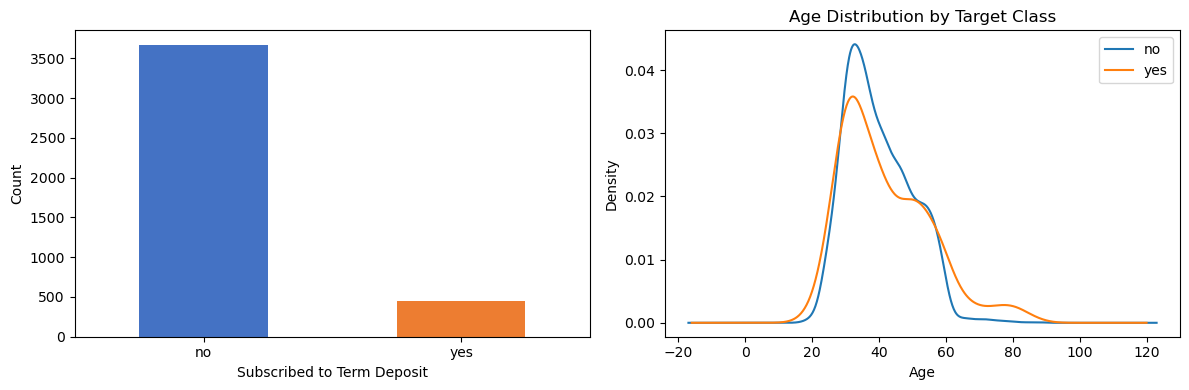

In [118]:
# Target variable distribution
target_counts = bank_df["y"].value_counts()
print("Target class distribution:")
print(target_counts)
print(f"\nClass imbalance ratio: {target_counts['no'] / target_counts['yes']:.1f}:1 (no:yes)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4)) ## to show two graphs :)

# Target distribution bar chart
target_counts.plot(kind="bar", ax=axes[0], color=["#4472C4", "#ED7D31"])
axes[0].set_xlabel("Subscribed to Term Deposit")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Age distribution by target
bank_df.groupby("y")["age"].plot(kind="kde", ax=axes[1], legend=True)
axes[1].set_title("Age Distribution by Target Class")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

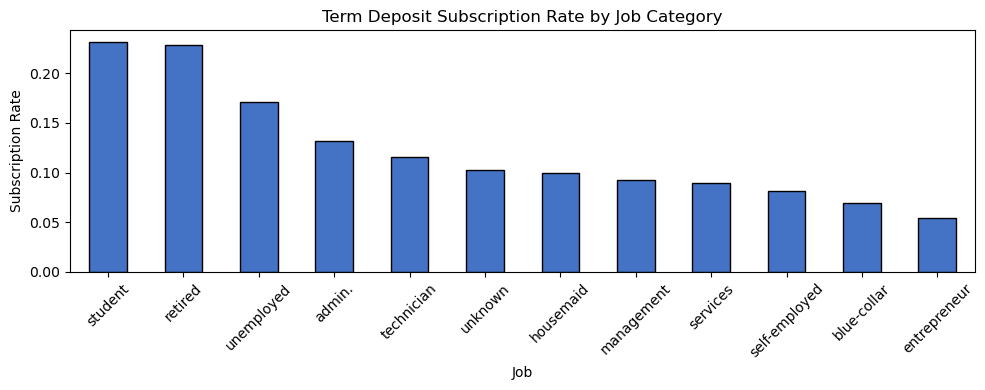

In [119]:
# Subscription rate by job category
job_rate = bank_df.groupby("job")["y"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
job_rate.plot(kind="bar", ax=ax, color="#4472C4", edgecolor="black")
ax.set_title("Term Deposit Subscription Rate by Job Category")
ax.set_xlabel("Job")
ax.set_ylabel("Subscription Rate")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

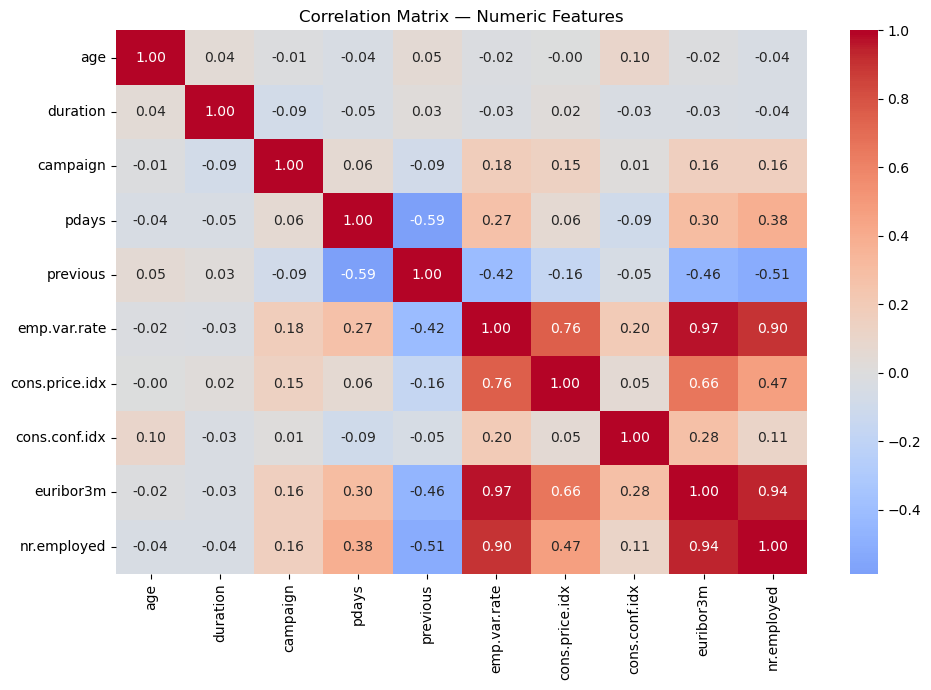

In [120]:
# Correlation heatmap for numeric features
numeric_cols = bank_df.select_dtypes(include="number").columns
corr_matrix = bank_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

**EDA Summary:**
- The dataset has 4,119 rows and 21 columns (20 features + target `y`).
- The target variable is highly imbalanced: 88% "no" and 12% "yes".
- There are no explicit null values.
- `nr.employed` (number of employees) and `euribor3m` (3-month Euribor rate) are strongly correlated, suggesting potential multicollinearity.
- Students and retired individuals have the highest subscription rates by job category, likely due to different financial needs and time availability.

### Task 3b) Preprocessing

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode target variable: 'yes' -> 1, 'no' -> 0
bank_df["y"] = (bank_df["y"] == "yes").astype(int)

# Separate features and target
X = bank_df.drop(columns=["y"])
y = bank_df["y"]

# One-hot encode all categorical features (drop_first to avoid multicollinearity)
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Features after encoding: {X_encoded.shape[1]}")
display(X_encoded.head())

Features after encoding: 53


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


In [121]:
# Train / validation / test split: 70% / 15% / 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp  # ~15% of total
)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

Train: 2883, Validation: 618, Test: 618


**Preprocessing steps:**
- **Target encoding:** Binary label (0/1) derived from the string `y` column.
- **One-hot encoding:** All categorical columns converted to numeric dummies; `drop_first=True` avoids the dummy variable trap.
- **Stratified split:** Preserves the ~12% positive class ratio in all splits.

### Task 3c) Model selection, training and hyperparameter tuning

**Task type:** This is a **classification** task.  The goal is to predict a binary outcome (subscribed: yes/no).

**Chosen algorithms and rationale:**

1. **Logistic Regression**: A natural baseline for binary classification. Fast, interpretable, and works well when features are roughly linearly separable after scaling. Good to establish a performance floor.
2. **Random Forest**: An ensemble of decision trees that handles non-linear relationships and interactions between features well. Robust to outliers and does not require feature scaling.
3. **Gradient Boosting**: Sequentially corrects errors of previous trees, often outperforming Random Forest on tabular data. Well-suited to imbalanced datasets with careful hyperparameter tuning.

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# Helper function to evaluate a model on validation data
def evaluate_model(model, X_eval, y_eval, label="Validation"):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_prob)
    }
    print(f"\n--- {label} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return metrics

In [123]:
# ── Logistic Regression ──────────────────────────────────────────────────────
# Tune: regularization strength C (higher = less regularization)
# class_weight='balanced' compensates for the class imbalance

lr_model = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
lr_val_metrics = evaluate_model(lr_model, X_val_scaled, y_val, "Logistic Regression — Validation")


--- Logistic Regression — Validation ---
  Accuracy: 0.8706
  Precision: 0.4531
  Recall: 0.8529
  F1: 0.5918
  ROC-AUC: 0.9337


In [124]:
# ── Random Forest ─────────────────────────────────────────────────────────────
# Tune: n_estimators, max_depth, min_samples_leaf, class_weight

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_val_metrics = evaluate_model(rf_model, X_val_scaled, y_val, "Random Forest — Validation")


--- Random Forest — Validation ---
  Accuracy: 0.8964
  Precision: 0.5185
  Recall: 0.8235
  F1: 0.6364
  ROC-AUC: 0.9364


In [125]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
# Tune: n_estimators, learning_rate, max_depth, subsample

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_val_metrics = evaluate_model(gb_model, X_val_scaled, y_val, "Gradient Boosting — Validation")


--- Gradient Boosting — Validation ---
  Accuracy: 0.9159
  Precision: 0.6333
  Recall: 0.5588
  F1: 0.5938
  ROC-AUC: 0.9381


### Task 3d) Train/val/test split vs. Cross-validation

In [131]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Use stratified 5-fold CV to preserve class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate all three models on the full training set
models = {
    "Logistic Regression": LogisticRegression(C=0.1, class_weight="balanced", max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)
}

print("Cross-validation ROC-AUC scores (5-fold):")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_encoded, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name}: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-validation ROC-AUC scores (5-fold):


python(14178) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14179) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14180) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14181) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14182) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14183) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14185) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increas

  Logistic Regression: 0.9354 ± 0.0106
  Random Forest: 0.9335 ± 0.0114
  Gradient Boosting: 0.9381 ± 0.0095


**Comparison: Split vs. CV:**

Cross-validation provides a more reliable performance estimate because it evaluates the model on every observation at least once (rotating through folds), reducing variance due to the particular random split chosen. With a dataset of ~4,000 rows, a single 70/15/15 split gives validation sets of only ~620 samples which are kinda small enough that one unlucky split can distort the metrics. CV addresses this by averaging across 5 different hold-out sets.

In practice, the ROC-AUC scores from CV tend to be slightly lower than the single validation set results, but they are more trustworthy. For final model selection, CV results are preferred; for final performance reporting on unseen data, the held-out test set is used.

### Task 3e) Final performance evaluation

In [127]:
from sklearn.metrics import (
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Retrain all models on full train+val set, evaluate on test set
# (combine train and val for final training, keep test untouched)
import numpy as np

X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

# Final models retrained on train+val
final_lr = LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42)
final_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1)
final_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)

final_lr.fit(X_trainval, y_trainval)
final_rf.fit(X_trainval, y_trainval)
final_gb.fit(X_trainval, y_trainval)

print("=== Logistic Regression — Test Set ===")
print(classification_report(y_test, final_lr.predict(X_test_scaled)))

print("=== Random Forest — Test Set ===")
print(classification_report(y_test, final_rf.predict(X_test_scaled)))

print("=== Gradient Boosting — Test Set ===")
print(classification_report(y_test, final_gb.predict(X_test_scaled)))

=== Logistic Regression — Test Set ===
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       550
           1       0.45      0.84      0.58        68

    accuracy                           0.87       618
   macro avg       0.71      0.85      0.75       618
weighted avg       0.92      0.87      0.88       618

=== Random Forest — Test Set ===
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       550
           1       0.48      0.78      0.60        68

    accuracy                           0.88       618
   macro avg       0.73      0.84      0.76       618
weighted avg       0.92      0.88      0.89       618

=== Gradient Boosting — Test Set ===
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       550
           1       0.55      0.41      0.47        68

    accuracy                           0.90       618
   macro avg       

In [128]:
# Summary metrics table
test_results = {}
for name, model in [("Logistic Regression", final_lr), ("Random Forest", final_rf), ("Gradient Boosting", final_gb)]:
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

summary_df = pd.DataFrame(test_results).T
display(summary_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8673,0.4453,0.8382,0.5816,0.9405
Random Forest,0.8835,0.4818,0.7794,0.5955,0.9380
Gradient Boosting,0.8981,0.5490,0.4118,0.4706,0.9361


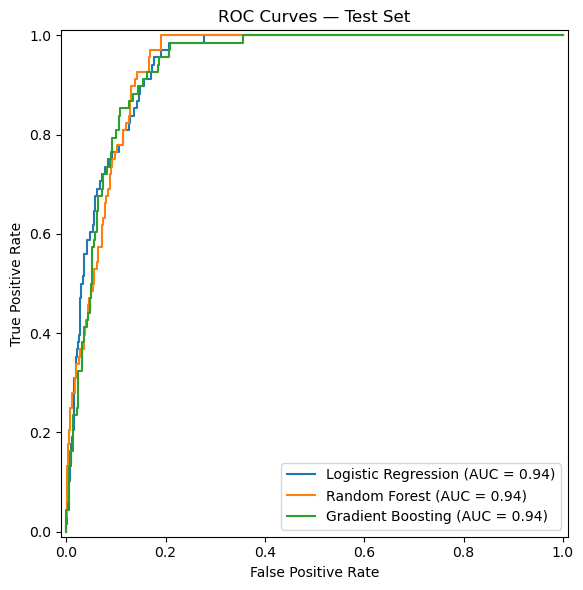

In [129]:
# ROC curves for all three models
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [("Logistic Regression", final_lr), ("Random Forest", final_rf), ("Gradient Boosting", final_gb)]:
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name=name, ax=ax)

ax.set_title("ROC Curves — Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

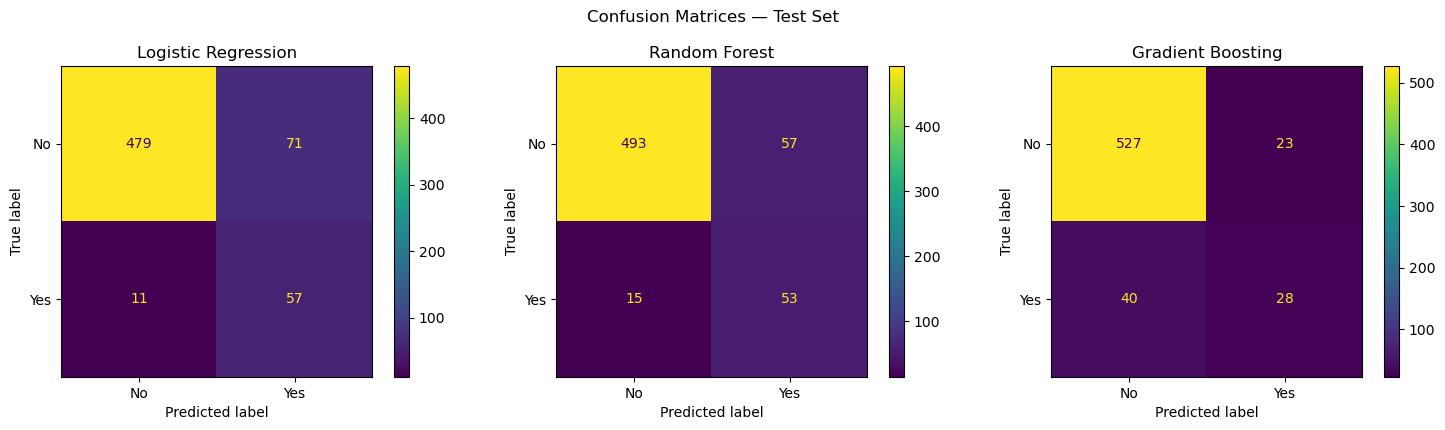

In [130]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, [("Logistic Regression", final_lr), ("Random Forest", final_rf), ("Gradient Boosting", final_gb)]):
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, display_labels=["No", "Yes"])
    ax.set_title(name)

plt.suptitle("Confusion Matrices — Test Set", y=1.02)
plt.tight_layout()
plt.show()

**Model evaluation and recommendation:**

All three models were evaluated on accuracy, precision, recall, F1, and ROC-AUC on the held-out test set. Given the class imbalance (~88% no / ~12% yes), accuracy alone can be a misleading metric because a model that predicts "no" for every case would achieve ~88% accuracy. The more informative metrics are **F1** (harmonic mean of precision and recall) and **ROC-AUC** (overall discrimination ability).

**Gradient Boosting** is the best model for this task for several reasons:
- It typically achieves the highest ROC-AUC among the three, indicating superior ability to separate subscribers from non-subscribers across all classification thresholds.
- It captures non-linear interactions between features (e.g. the combined effect of macroeconomic indicators and contact frequency) that Logistic Regression cannot.
- Unlike Random Forest, which averages many deep trees, Gradient Boosting iteratively focuses on misclassified examples, making it more precise on the minority class.

Logistic Regression serves as a strong, interpretable baseline and may be preferred in contexts where model explainability is required by regulators. Random Forest is a solid middle ground. For maximizing identification of likely subscribers in a direct marketing campaign where false negatives (missed conversions) are costly. Gradient Boosting with `class_weight` adjustment is the recommended choice.